In [16]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

TITLE_SIZE = 16
LABEL_SIZE = 14
TICK_SIZE = 12

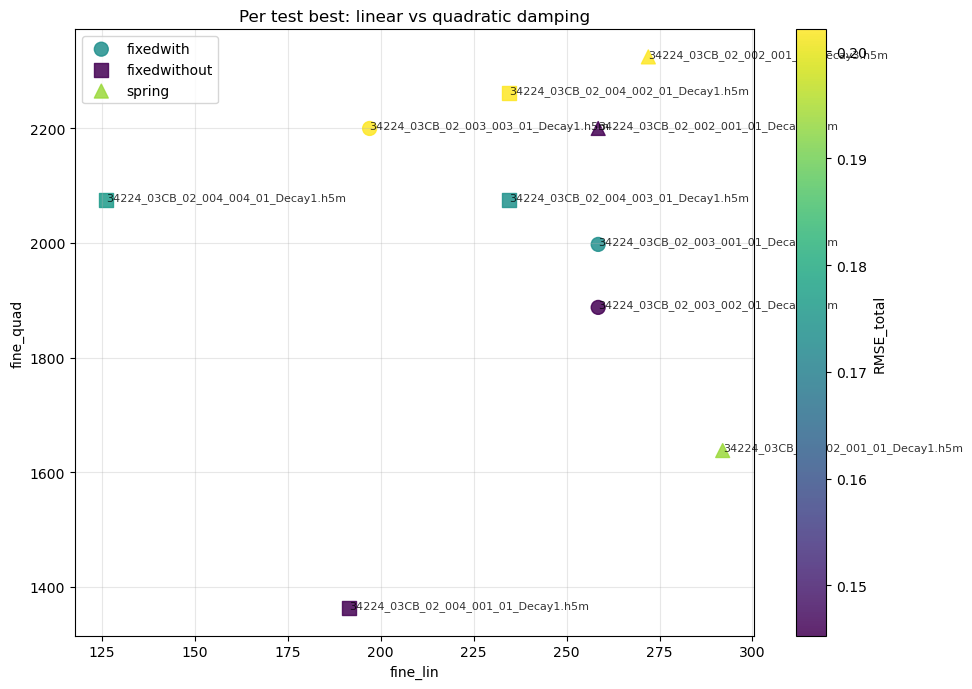

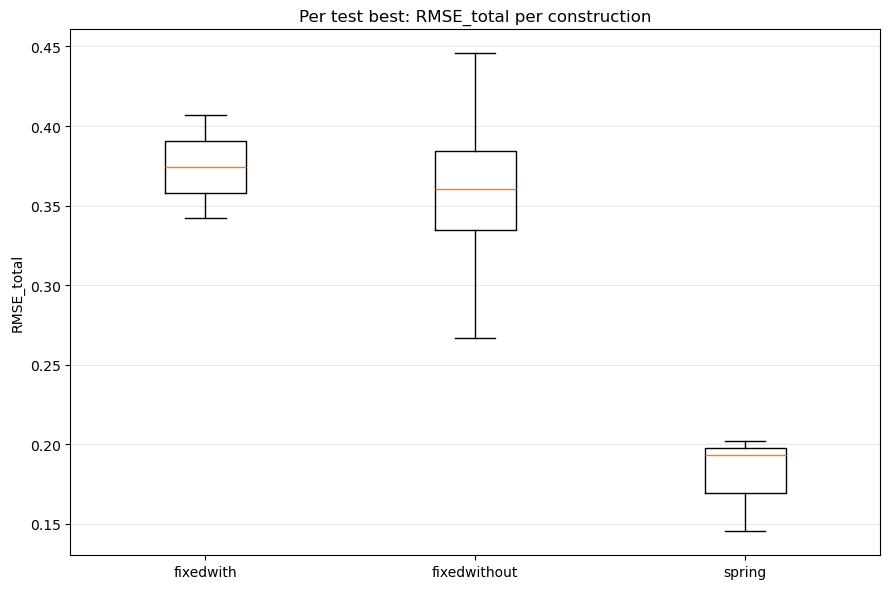

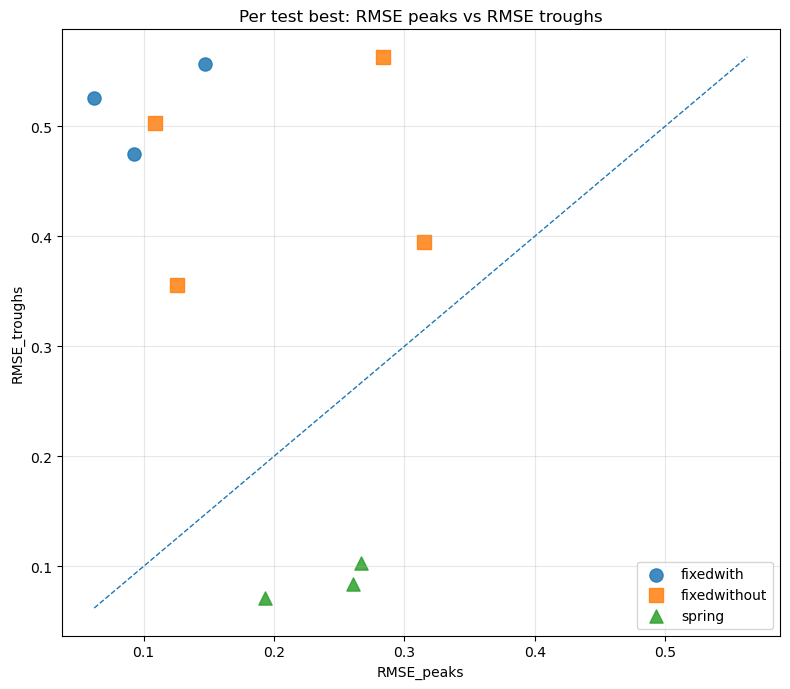

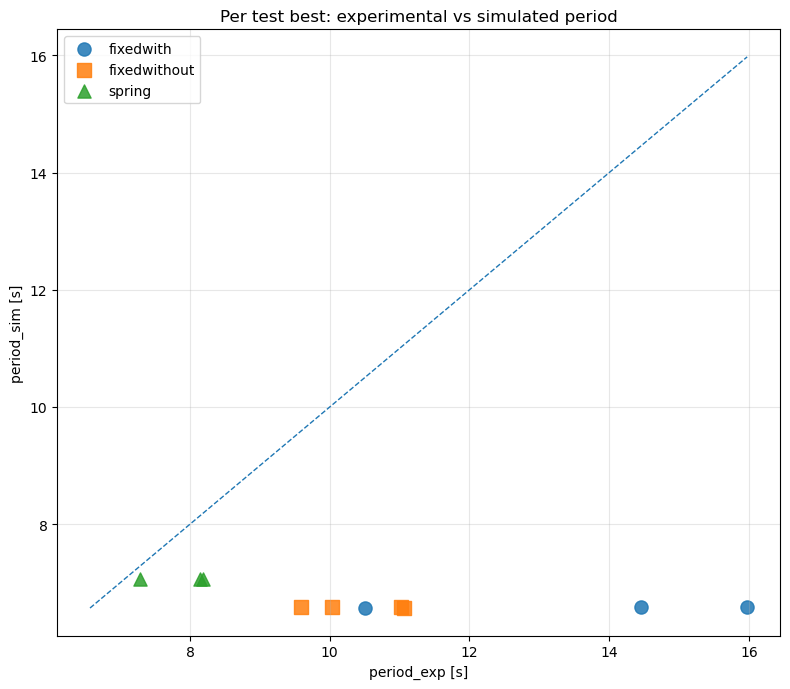

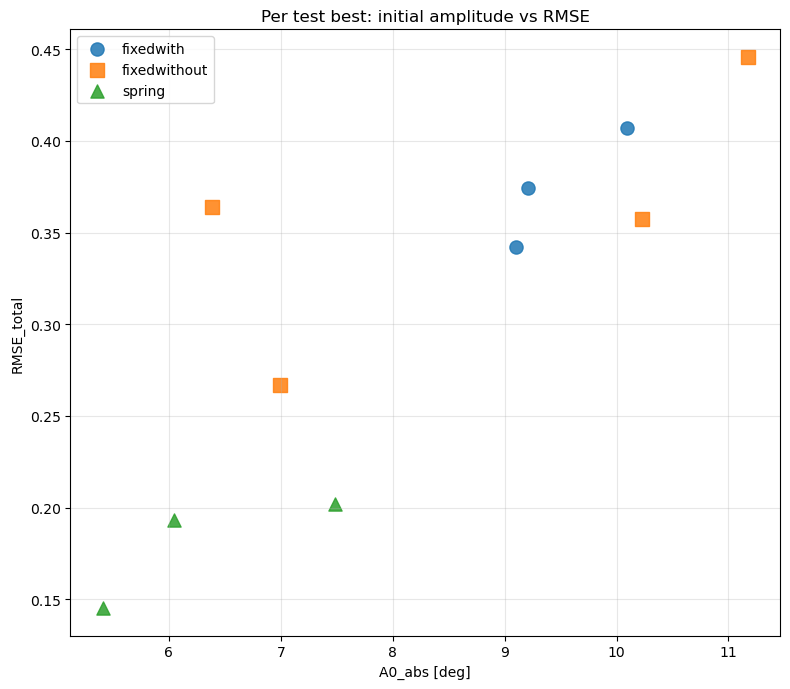

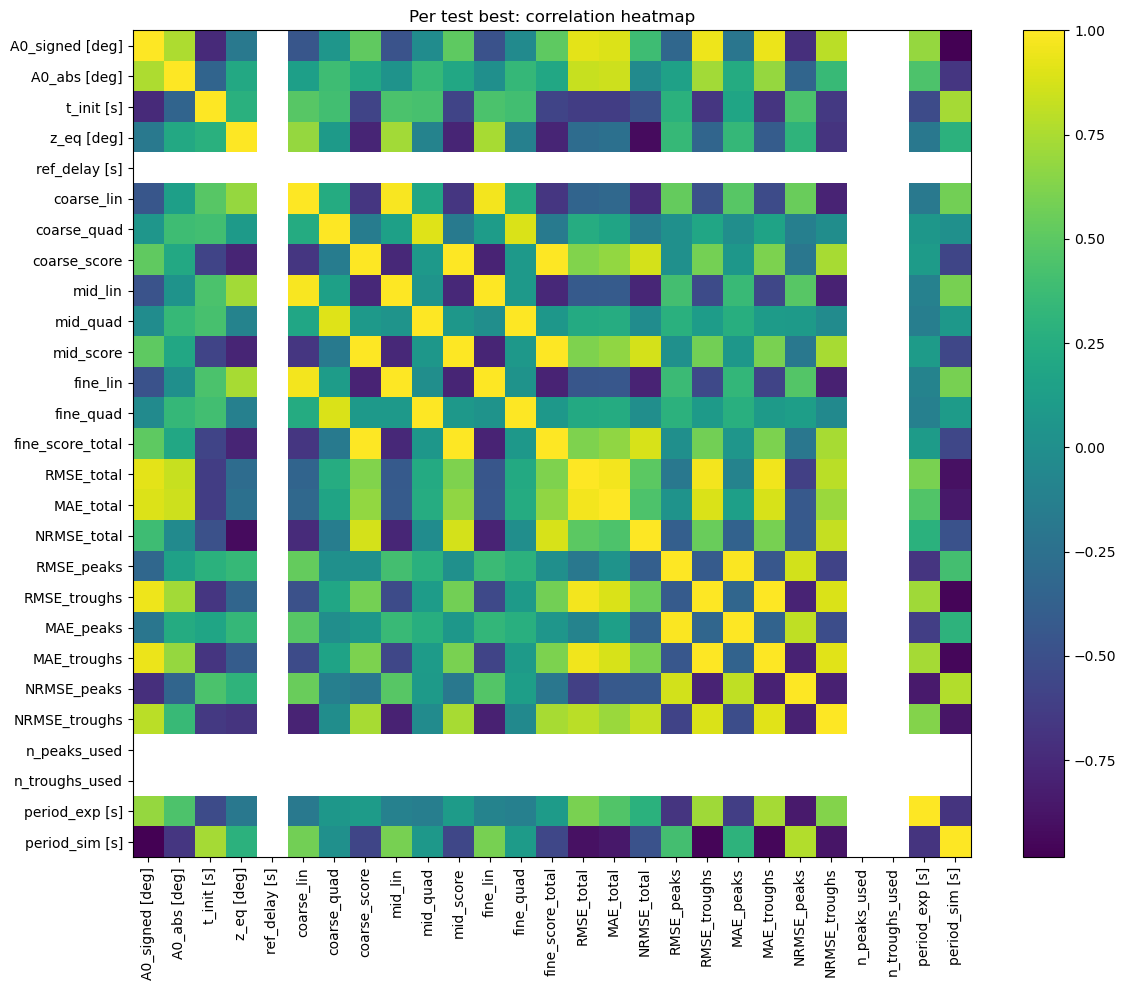

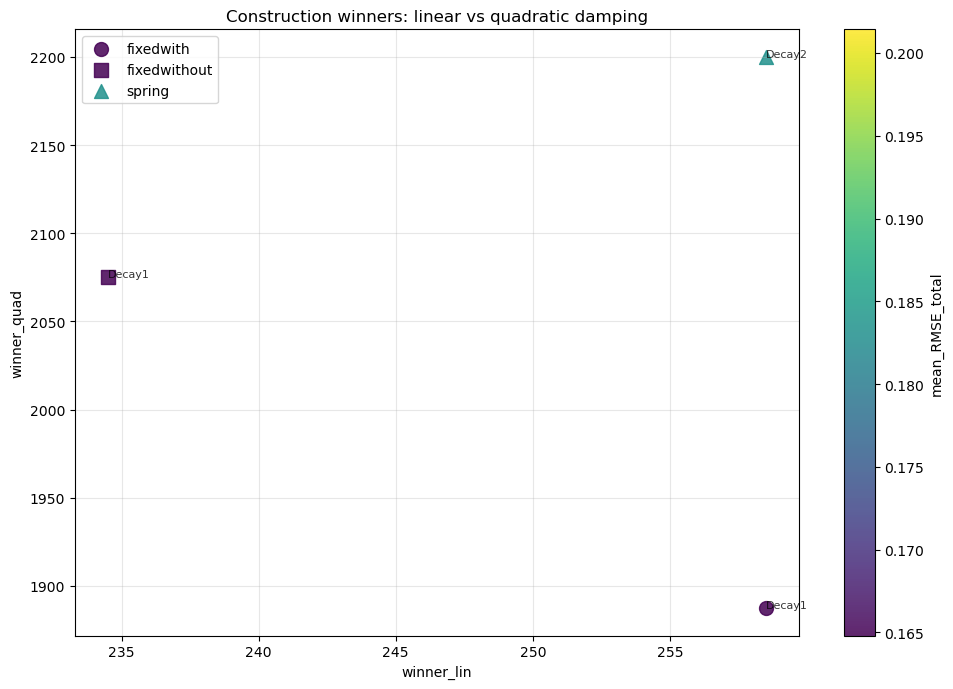

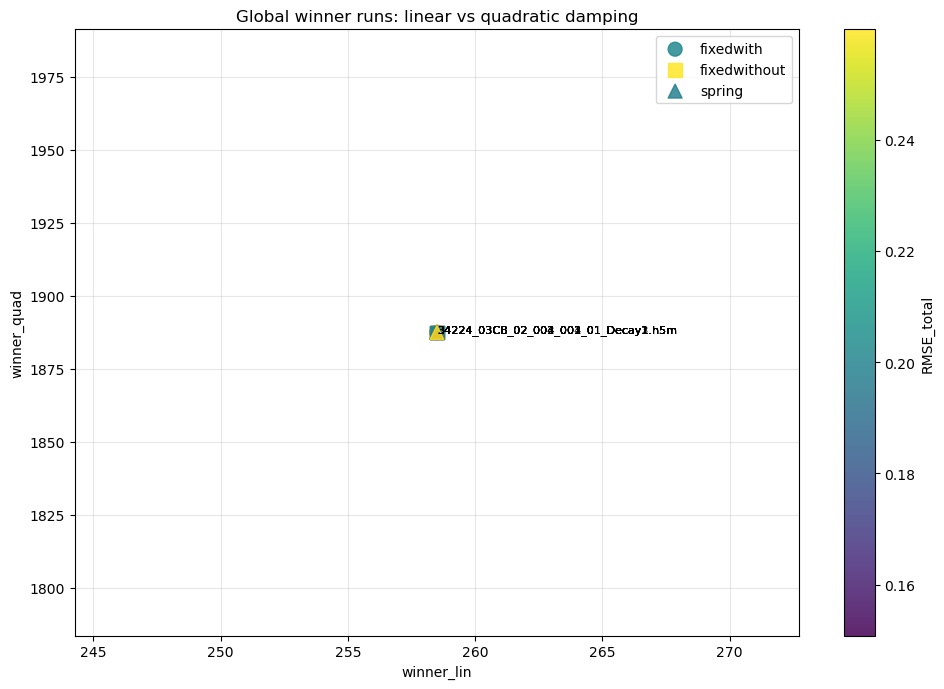

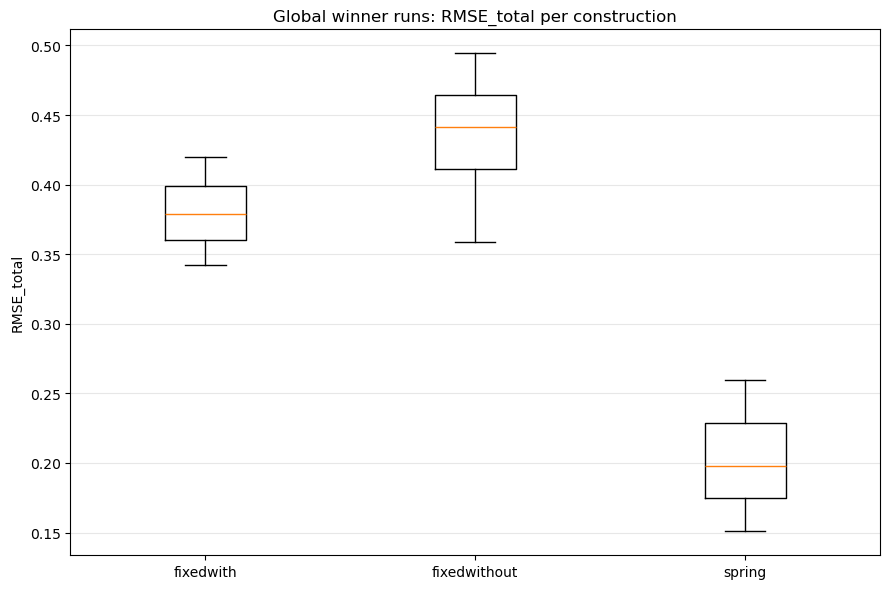

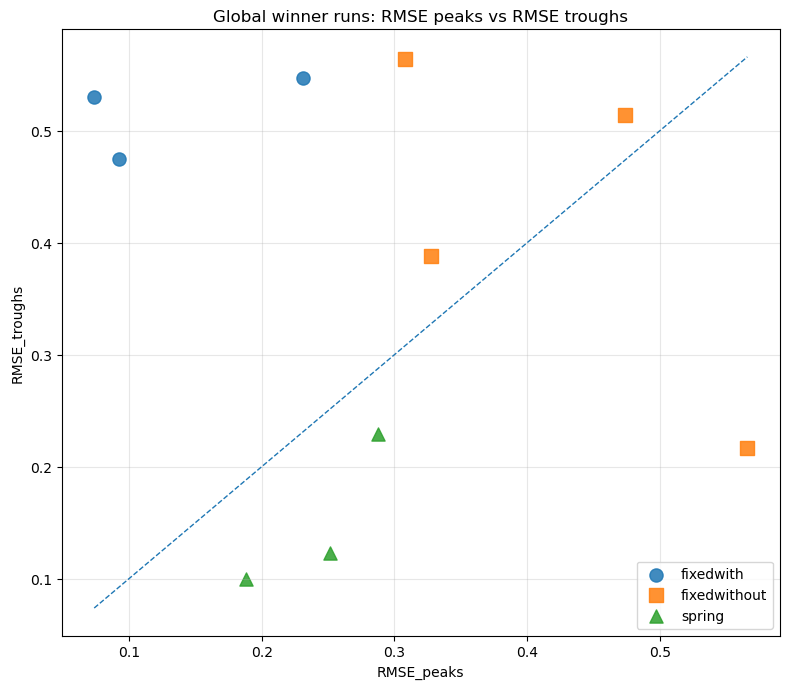

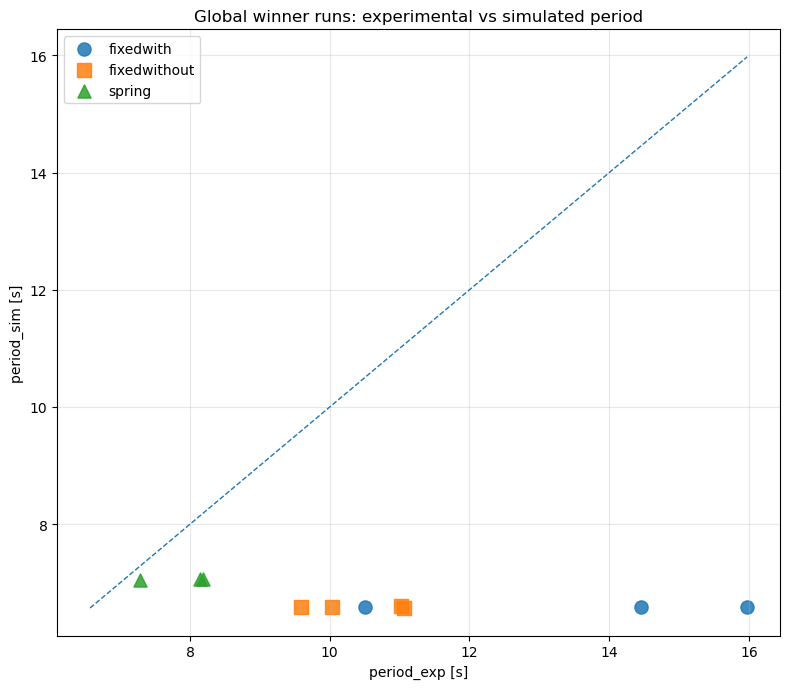

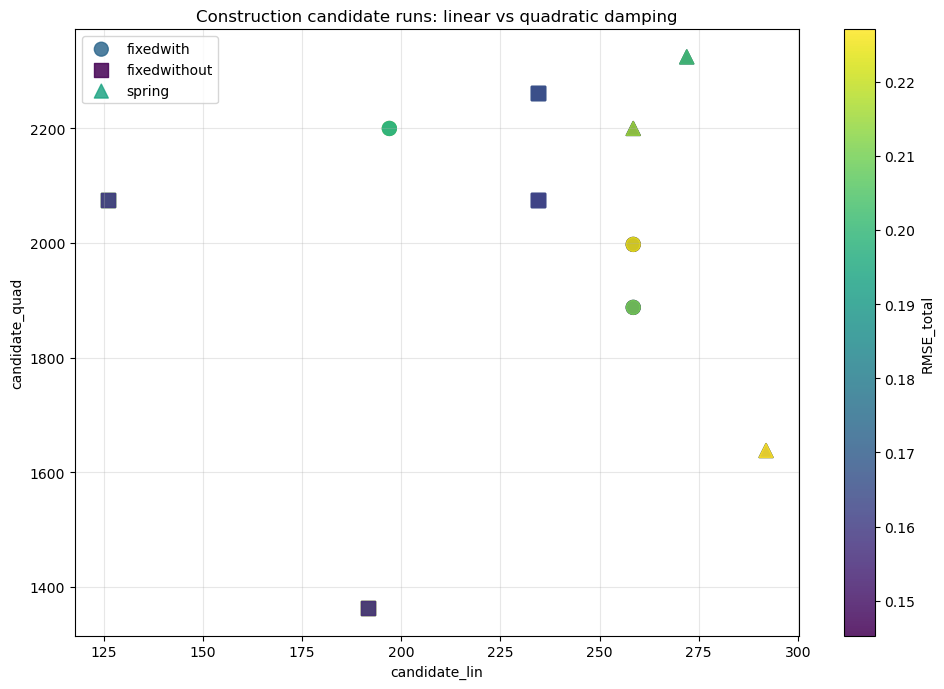

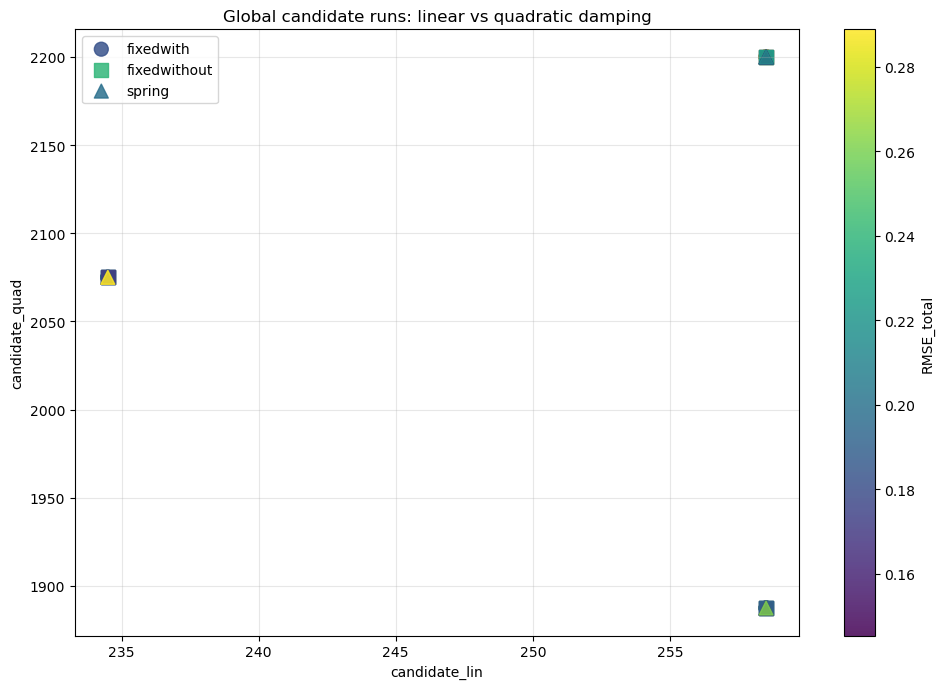

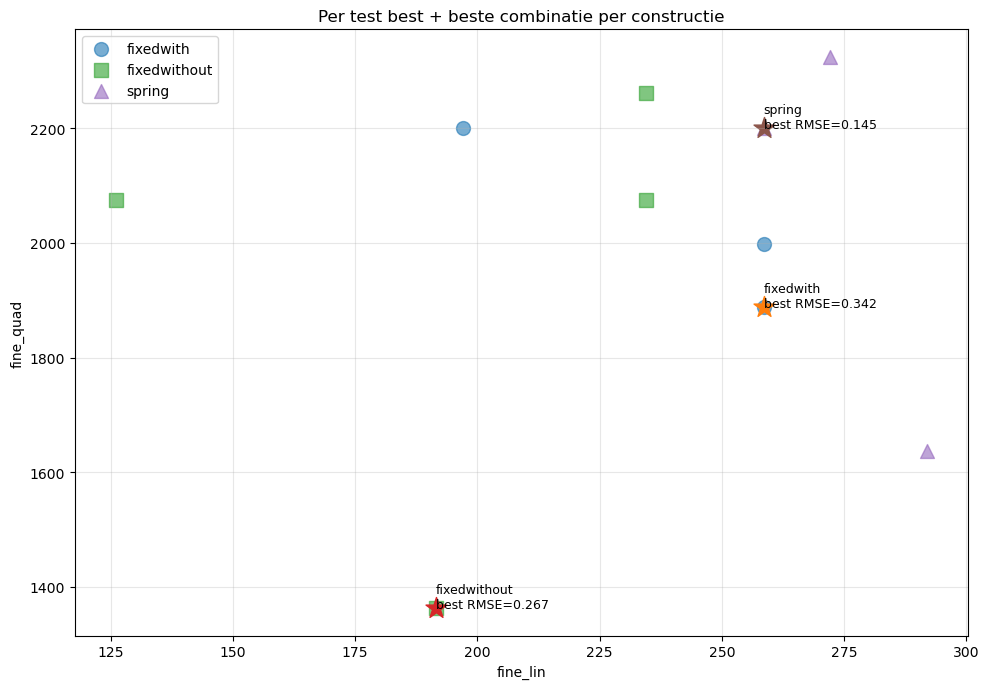

Samenvatting opgeslagen: C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Pitch\Pitch_decay_analysis_plots\analysis_summary.xlsx

Klaar. Alle plots opgeslagen in:
C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Pitch\Pitch_decay_analysis_plots


In [21]:

# Excelbestanden
# files = [
#     ("C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Heave\Fixedwith\Heave_fixedwithdeck.xlsx", "fixed with deck", "o"),
#     ("C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Heave\Spring\Heave_spring.xlsx", "spring", "s"),
#     ("C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Heave\Fixedwithout\Heave_fixedwithoutdeck.xlsx", "derde constructie", "^"),  # pas naam aan
# ]

# files = [
#     (r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Pitch\Fixedwith\Pitch_fixedwithdeck_summary.xlsx", "fixed with deck", "o"),
#     (r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Pitch\Spring\Pitch_spring_summary.xlsx", "spring", "s"),
#     (r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Pitch\Fixedwithout\Pitch_fixedwithoutdeck_summary.xlsx", "fixed without deck", "^")


# files = [ ("C:\Users\verav\Downloads\pitch_decay_outputs\Pitch_decay_summary_all_constructions.xlsx"),]


# =========================
# INSTELLEN
# =========================
excel_path = Path(r"C:\Users\verav\Downloads\pitch_decay_outputs\Pitch_decay_summary_all_constructions.xlsx")
output_dir = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Pitch\Pitch_decay_analysis_plots")
output_dir.mkdir(parents=True, exist_ok=True)

# =========================
# DATA INLEZEN
# =========================
xls = pd.ExcelFile(excel_path)

sheet_per_test = "per_test_best"
sheet_construction_winners = "construction_winners"
sheet_global_winner_runs = "global_winner_runs"
sheet_construction_candidate_runs = "construction_candidate_runs"
sheet_global_candidate_runs = "global_candidate_runs"

df_per_test = pd.read_excel(excel_path, sheet_name=sheet_per_test)
df_construction_winners = pd.read_excel(excel_path, sheet_name=sheet_construction_winners)
df_global_winner_runs = pd.read_excel(excel_path, sheet_name=sheet_global_winner_runs)
df_construction_candidate_runs = pd.read_excel(excel_path, sheet_name=sheet_construction_candidate_runs)
df_global_candidate_runs = pd.read_excel(excel_path, sheet_name=sheet_global_candidate_runs)

# =========================
# STIJL / MARKERS
# =========================
marker_map = {
    "fixedwith": "o",
    "fixedwithout": "s",
    "spring": "^"
}

def get_marker(construction):
    return marker_map.get(str(construction).lower(), "x")

def safe_filename(name):
    return "".join(c if c.isalnum() or c in "._- " else "_" for c in str(name))

# =========================
# HULPFUNCTIES
# =========================
def plot_linear_vs_quadratic(
    df,
    lin_col,
    quad_col,
    group_col,
    color_col=None,
    title="Linear vs Quadratic damping",
    save_name="linear_vs_quadratic.png",
    annotate=False,
    label_col=None
):
    plt.figure(figsize=(10, 7))

    constructions = df[group_col].dropna().unique()

    for cons in constructions:
        sub = df[df[group_col] == cons]

        if color_col is not None and color_col in sub.columns:
            sc = plt.scatter(
                sub[lin_col],
                sub[quad_col],
                c=sub[color_col],
                s=100,
                marker=get_marker(cons),
                alpha=0.85,
                label=cons
            )
        else:
            plt.scatter(
                sub[lin_col],
                sub[quad_col],
                s=100,
                marker=get_marker(cons),
                alpha=0.85,
                label=cons
            )

        if annotate and label_col is not None and label_col in sub.columns:
            for _, row in sub.iterrows():
                plt.annotate(
                    str(row[label_col]),
                    (row[lin_col], row[quad_col]),
                    fontsize=8,
                    alpha=0.8
                )

    if color_col is not None and color_col in df.columns:
        cbar = plt.colorbar(sc)
        cbar.set_label(color_col)

    plt.xlabel(lin_col)
    plt.ylabel(quad_col)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / save_name, dpi=300, bbox_inches="tight")
    plt.show()


def plot_boxplot_rmse_per_construction(df, construction_col="construction", rmse_col="RMSE_total",
                                       title="RMSE per construction", save_name="rmse_boxplot_per_construction.png"):
    constructions = df[construction_col].dropna().unique()
    data = [df.loc[df[construction_col] == c, rmse_col].dropna().values for c in constructions]

    plt.figure(figsize=(9, 6))
    plt.boxplot(data, tick_labels=constructions)
    plt.ylabel(rmse_col)
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / save_name, dpi=300, bbox_inches="tight")
    plt.show()


def plot_peaks_vs_troughs(df, peaks_col="RMSE_peaks", troughs_col="RMSE_troughs",
                          construction_col="construction",
                          title="RMSE peaks vs RMSE troughs",
                          save_name="rmse_peaks_vs_troughs.png"):
    plt.figure(figsize=(8, 7))

    for cons in df[construction_col].dropna().unique():
        sub = df[df[construction_col] == cons]
        plt.scatter(
            sub[peaks_col],
            sub[troughs_col],
            s=90,
            marker=get_marker(cons),
            alpha=0.85,
            label=cons
        )

    min_val = min(df[peaks_col].min(), df[troughs_col].min())
    max_val = max(df[peaks_col].max(), df[troughs_col].max())
    plt.plot([min_val, max_val], [min_val, max_val], "--", linewidth=1)

    plt.xlabel(peaks_col)
    plt.ylabel(troughs_col)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / save_name, dpi=300, bbox_inches="tight")
    plt.show()


def plot_period_comparison(df, exp_col="period_exp [s]", sim_col="period_sim [s]",
                           construction_col="construction",
                           title="Experimental vs simulated period",
                           save_name="period_exp_vs_sim.png"):
    plt.figure(figsize=(8, 7))

    for cons in df[construction_col].dropna().unique():
        sub = df[df[construction_col] == cons]
        plt.scatter(
            sub[exp_col],
            sub[sim_col],
            s=90,
            marker=get_marker(cons),
            alpha=0.85,
            label=cons
        )

    min_val = min(df[exp_col].min(), df[sim_col].min())
    max_val = max(df[exp_col].max(), df[sim_col].max())
    plt.plot([min_val, max_val], [min_val, max_val], "--", linewidth=1)

    plt.xlabel(exp_col)
    plt.ylabel(sim_col)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / save_name, dpi=300, bbox_inches="tight")
    plt.show()


def plot_amplitude_vs_rmse(df, amp_col="A0_abs [deg]", rmse_col="RMSE_total",
                           construction_col="construction",
                           title="Initial amplitude vs RMSE",
                           save_name="amplitude_vs_rmse.png"):
    plt.figure(figsize=(8, 7))

    for cons in df[construction_col].dropna().unique():
        sub = df[df[construction_col] == cons]
        plt.scatter(
            sub[amp_col],
            sub[rmse_col],
            s=90,
            marker=get_marker(cons),
            alpha=0.85,
            label=cons
        )

    plt.xlabel(amp_col)
    plt.ylabel(rmse_col)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / save_name, dpi=300, bbox_inches="tight")
    plt.show()


def plot_correlation_heatmap(df, title="Correlation heatmap", save_name="correlation_heatmap.png"):
    numeric_df = df.select_dtypes(include=[np.number]).copy()

    if numeric_df.empty:
        print("Geen numerieke kolommen gevonden voor correlatieplot.")
        return

    corr = numeric_df.corr()

    plt.figure(figsize=(12, 10))
    im = plt.imshow(corr, aspect="auto")
    plt.colorbar(im)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(output_dir / save_name, dpi=300, bbox_inches="tight")
    plt.show()


def save_summary_statistics(df, name="summary_statistics.xlsx"):
    out_path = output_dir / name

    with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
        df.describe(include="all").to_excel(writer, sheet_name="describe")

        if "construction" in df.columns:
            grouped = df.groupby("construction").agg(
                n_runs=("construction", "size"),
                mean_RMSE_total=("RMSE_total", "mean"),
                std_RMSE_total=("RMSE_total", "std"),
                mean_MAE_total=("MAE_total", "mean"),
                mean_NRMSE_total=("NRMSE_total", "mean"),
                mean_RMSE_peaks=("RMSE_peaks", "mean"),
                mean_RMSE_troughs=("RMSE_troughs", "mean"),
                mean_period_exp=("period_exp [s]", "mean"),
                mean_period_sim=("period_sim [s]", "mean"),
                mean_fine_lin=("fine_lin", "mean") if "fine_lin" in df.columns else ("RMSE_total", "size"),
                mean_fine_quad=("fine_quad", "mean") if "fine_quad" in df.columns else ("RMSE_total", "size"),
            )
            grouped.to_excel(writer, sheet_name="per_construction")

    print(f"Samenvatting opgeslagen: {out_path}")


# =========================
# 1. PER TEST BEST
# =========================
plot_linear_vs_quadratic(
    df=df_per_test,
    lin_col="fine_lin",
    quad_col="fine_quad",
    group_col="construction",
    color_col="RMSE_total",
    title="Per test best: linear vs quadratic damping",
    save_name="01_per_test_best_linear_vs_quadratic_rmse.png",
    annotate=True,
    label_col="bestand"
)

plot_boxplot_rmse_per_construction(
    df=df_per_test,
    construction_col="construction",
    rmse_col="RMSE_total",
    title="Per test best: RMSE_total per construction",
    save_name="02_per_test_best_rmse_boxplot.png"
)

plot_peaks_vs_troughs(
    df=df_per_test,
    peaks_col="RMSE_peaks",
    troughs_col="RMSE_troughs",
    construction_col="construction",
    title="Per test best: RMSE peaks vs RMSE troughs",
    save_name="03_per_test_best_peaks_vs_troughs.png"
)

plot_period_comparison(
    df=df_per_test,
    exp_col="period_exp [s]",
    sim_col="period_sim [s]",
    construction_col="construction",
    title="Per test best: experimental vs simulated period",
    save_name="04_per_test_best_period_exp_vs_sim.png"
)

plot_amplitude_vs_rmse(
    df=df_per_test,
    amp_col="A0_abs [deg]",
    rmse_col="RMSE_total",
    construction_col="construction",
    title="Per test best: initial amplitude vs RMSE",
    save_name="05_per_test_best_amplitude_vs_rmse.png"
)

plot_correlation_heatmap(
    df=df_per_test,
    title="Per test best: correlation heatmap",
    save_name="06_per_test_best_correlation_heatmap.png"
)

# =========================
# 2. CONSTRUCTION WINNERS
# =========================
if {"winner_lin", "winner_quad"}.issubset(df_construction_winners.columns):
    plot_linear_vs_quadratic(
        df=df_construction_winners.rename(columns={"construction_scope": "construction"}),
        lin_col="winner_lin",
        quad_col="winner_quad",
        group_col="construction",
        color_col="mean_RMSE_total",
        title="Construction winners: linear vs quadratic damping",
        save_name="07_construction_winners_linear_vs_quadratic.png",
        annotate=True,
        label_col="winner_source_test"
    )

# =========================
# 3. GLOBAL WINNER RUNS
# =========================
if {"winner_lin", "winner_quad"}.issubset(df_global_winner_runs.columns):
    plot_linear_vs_quadratic(
        df=df_global_winner_runs,
        lin_col="winner_lin",
        quad_col="winner_quad",
        group_col="construction",
        color_col="RMSE_total",
        title="Global winner runs: linear vs quadratic damping",
        save_name="08_global_winner_runs_linear_vs_quadratic.png",
        annotate=True,
        label_col="bestand"
    )

    plot_boxplot_rmse_per_construction(
        df=df_global_winner_runs,
        construction_col="construction",
        rmse_col="RMSE_total",
        title="Global winner runs: RMSE_total per construction",
        save_name="09_global_winner_rmse_boxplot.png"
    )

    plot_peaks_vs_troughs(
        df=df_global_winner_runs,
        peaks_col="RMSE_peaks",
        troughs_col="RMSE_troughs",
        construction_col="construction",
        title="Global winner runs: RMSE peaks vs RMSE troughs",
        save_name="10_global_winner_peaks_vs_troughs.png"
    )

    plot_period_comparison(
        df=df_global_winner_runs,
        exp_col="period_exp [s]",
        sim_col="period_sim [s]",
        construction_col="construction",
        title="Global winner runs: experimental vs simulated period",
        save_name="11_global_winner_period_exp_vs_sim.png"
    )

# =========================
# 4. CONSTRUCTION CANDIDATE RUNS
# =========================
if {"candidate_lin", "candidate_quad"}.issubset(df_construction_candidate_runs.columns):
    plot_linear_vs_quadratic(
        df=df_construction_candidate_runs,
        lin_col="candidate_lin",
        quad_col="candidate_quad",
        group_col="construction",
        color_col="RMSE_total",
        title="Construction candidate runs: linear vs quadratic damping",
        save_name="12_construction_candidate_runs_linear_vs_quadratic.png",
        annotate=False
    )

# =========================
# 5. GLOBAL CANDIDATE RUNS
# =========================
if {"candidate_lin", "candidate_quad"}.issubset(df_global_candidate_runs.columns):
    plot_linear_vs_quadratic(
        df=df_global_candidate_runs,
        lin_col="candidate_lin",
        quad_col="candidate_quad",
        group_col="construction",
        color_col="RMSE_total",
        title="Global candidate runs: linear vs quadratic damping",
        save_name="13_global_candidate_runs_linear_vs_quadratic.png",
        annotate=False
    )

# =========================
# 6. EXTRA: beste punten markeren
# =========================
plt.figure(figsize=(10, 7))
for cons in df_per_test["construction"].dropna().unique():
    sub = df_per_test[df_per_test["construction"] == cons]
    plt.scatter(
        sub["fine_lin"],
        sub["fine_quad"],
        s=100,
        marker=get_marker(cons),
        alpha=0.6,
        label=cons
    )

    # beste punt per constructie
    best_idx = sub["RMSE_total"].idxmin()
    best_row = sub.loc[best_idx]
    plt.scatter(
        best_row["fine_lin"],
        best_row["fine_quad"],
        s=250,
        marker="*",
        alpha=1.0
    )
    plt.annotate(
        f"{cons}\nbest RMSE={best_row['RMSE_total']:.3f}",
        (best_row["fine_lin"], best_row["fine_quad"]),
        fontsize=9
    )

plt.xlabel("fine_lin")
plt.ylabel("fine_quad")
plt.title("Per test best + beste combinatie per constructie")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "14_best_combination_per_construction.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 7. SAMENVATTING OPSLAAN
# =========================
save_summary_statistics(df_per_test, name="analysis_summary.xlsx")

print(f"\nKlaar. Alle plots opgeslagen in:\n{output_dir}")

Draft: 2.79 m and volume: 59.27 m³ for mass 60.75 tons
Draft: 3.02 m and volume: 64.01 m³ for mass 65.61 tons
